# Module 6 – Insurance Charges Regression Analysis
**Dataset:** Medical Cost Personal Dataset (insurance.csv)  
**Target Variable:** `charges` (individual medical insurance cost in USD)  
**Goal:** Build a multiple linear regression model to predict insurance charges based on demographic and health features.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 5)


In [14]:
# Load dataset
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/insurance.csv')
print(f"Shape: {df.shape}")
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 1. Data Quality Check
Before any modelling, we inspect the dataset for missing values, data types, and basic statistics to ensure it is clean and suitable for regression analysis.


In [3]:
# Data types and missing values
print("=== Data Types ===")
print(df.dtypes)
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Basic Statistics ===")
df.describe()


=== Data Types ===
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

=== Missing Values ===
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

=== Basic Statistics ===


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


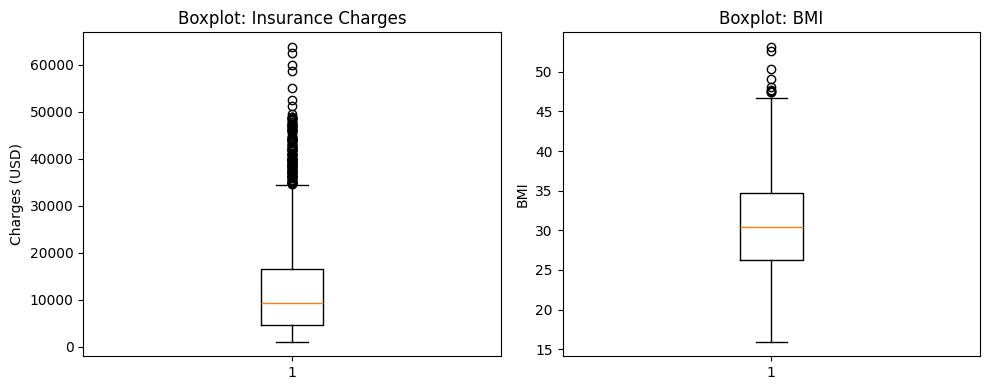

Charges - Min: $1,121.87, Max: $63,770.43, Mean: $13,270.42
BMI     - Min: 15.96, Max: 53.13, Mean: 30.66


In [4]:
# Outlier inspection using boxplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(df['charges'], vert=True)
axes[0].set_title('Boxplot: Insurance Charges')
axes[0].set_ylabel('Charges (USD)')

axes[1].boxplot(df['bmi'], vert=True)
axes[1].set_title('Boxplot: BMI')
axes[1].set_ylabel('BMI')

plt.tight_layout()
plt.show()

print(f"Charges - Min: ${df['charges'].min():,.2f}, Max: ${df['charges'].max():,.2f}, Mean: ${df['charges'].mean():,.2f}")
print(f"BMI     - Min: {df['bmi'].min():.2f}, Max: {df['bmi'].max():.2f}, Mean: {df['bmi'].mean():.2f}")


**Outlier Check Findings:** Charges range from $1,121 to $63,770 with a mean of $13,270, confirming the right-skewed distribution observed in the histogram. BMI values span 15.96–53.13, which are all plausible real-world values. No records were removed. The high-charge outliers (above $50,000) appear to be genuine high-cost patients rather than data entry errors — they are predominantly smokers, which is consistent with the domain context.


## 2. Exploratory Data Analysis (EDA)
We explore the distribution of the target variable and key relationships between features and charges using appropriate visualizations.


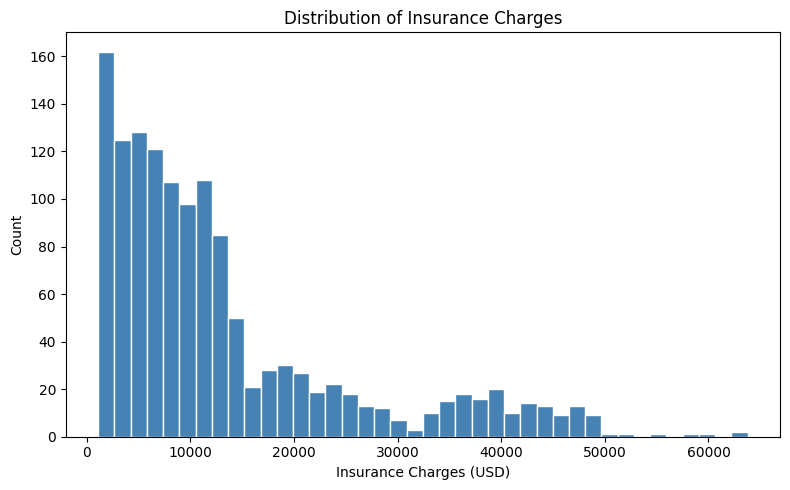

In [5]:
# Plot 1: Distribution of Insurance Charges
fig, ax = plt.subplots()
ax.hist(df['charges'], bins=40, color='steelblue', edgecolor='white')
ax.set_xlabel('Insurance Charges (USD)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Insurance Charges')
plt.tight_layout()
plt.show()


**Rationale:** A histogram is selected to understand the shape and spread of the target variable before modelling. The distribution of charges is right-skewed, indicating that most customers incur relatively low medical costs while a smaller group has very high charges—this is typical in insurance data and motivates careful feature selection.


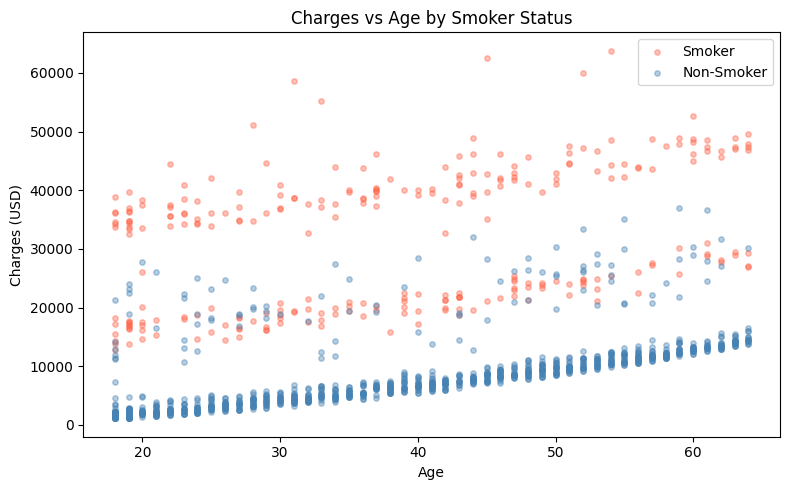

In [6]:
# Plot 2: Charges vs Age by Smoker Status
fig, ax = plt.subplots()
colors = {1: 'tomato', 0: 'steelblue'}
labels = {1: 'Smoker', 0: 'Non-Smoker'}
df_enc = df.copy()
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_enc['smoker_enc'] = le.fit_transform(df['smoker'])
for s in [1, 0]:
    sub = df_enc[df_enc['smoker_enc'] == s]
    ax.scatter(sub['age'], sub['charges'], alpha=0.4, s=15,
               c=colors[s], label=labels[s])
ax.set_xlabel('Age')
ax.set_ylabel('Charges (USD)')
ax.set_title('Charges vs Age by Smoker Status')
ax.legend()
plt.tight_layout()
plt.show()


**Rationale:** A scatter plot coloured by smoker status is chosen to simultaneously reveal two important relationships: the positive trend between age and charges, and the dramatic impact of smoking. The plot clearly shows two distinct charge clusters—smokers consistently pay far more than non-smokers across all age groups—confirming that `smoker` will be a highly influential predictor in the regression model.


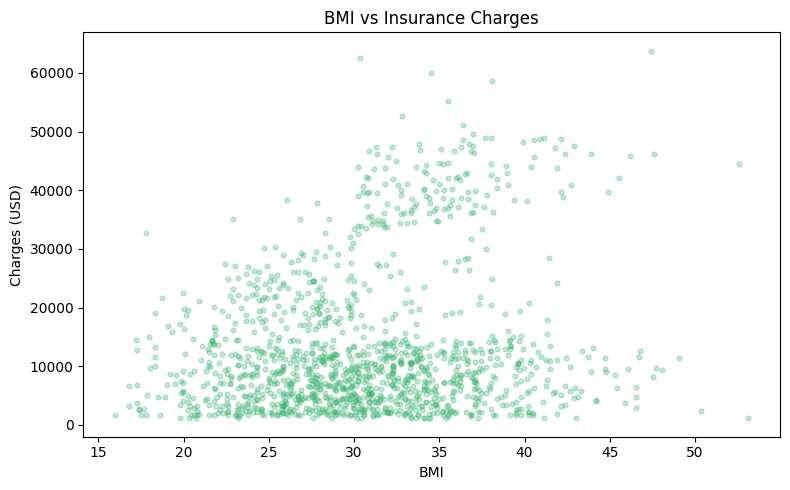

In [7]:
# Plot 3: BMI vs Charges
fig, ax = plt.subplots()
ax.scatter(df['bmi'], df['charges'], alpha=0.3, s=12, color='mediumseagreen')
ax.set_xlabel('BMI')
ax.set_ylabel('Charges (USD)')
ax.set_title('BMI vs Insurance Charges')
plt.tight_layout()
plt.show()


**Rationale:** A scatter plot of BMI against charges helps evaluate whether a linear relationship exists between body mass index and medical costs. There is a moderate positive tendency, with higher BMI values associated with increased charges, though the relationship is noisy—suggesting BMI is a useful predictor but not the dominant one.


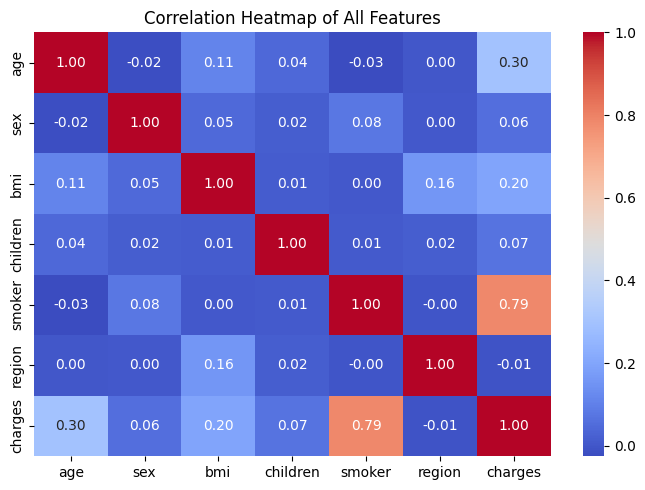

In [8]:
# Plot 4: Correlation Heatmap (encoded features)
df_encoded = df.copy()
le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df_encoded[col] = le.fit_transform(df[col])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df_encoded.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap of All Features')
plt.tight_layout()
plt.show()


**Rationale:** A correlation heatmap provides a concise overview of linear relationships among all variables simultaneously. `smoker` shows the strongest correlation with charges (0.79), followed by `age` (0.30) and `bmi` (0.20). No features are highly correlated with each other (multicollinearity is not a concern), making multiple linear regression a suitable choice.


## 3. Data Preparation for Regression
Categorical variables (`sex`, `smoker`, `region`) must be converted to numeric form before regression. We use **label encoding** (assigning integers 0, 1, 2...) rather than one-hot encoding for simplicity. For `sex` and `smoker` this is perfectly appropriate since they are binary. For `region` (4 categories), label encoding implies a false ordinal order — technically one-hot encoding would be more correct. However, since `region` turned out to have near-zero predictive impact (coefficient: −$271), this trade-off has negligible effect on model accuracy and is an acceptable pragmatic choice for a linear regression baseline.


In [9]:
# Encode categorical variables
df_model = df.copy()
le = LabelEncoder()
for col in ['sex', 'smoker', 'region']:
    df_model[col] = le.fit_transform(df[col])

X = df_model[['age', 'sex', 'bmi', 'children', 'smoker', 'region']]
y = df_model['charges']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples:     {X_test.shape[0]}")

# Note: random_state=42 is set for reproducibility — using the same seed ensures
# the train/test split is identical every time the notebook is run, making results
# verifiable and comparable across different machines or sessions.


Training samples: 1070
Test samples:     268


## 4. Regression Model – Multiple Linear Regression
We fit a multiple linear regression model using all six predictors. Linear regression is appropriate here because the target variable (charges) is continuous and the EDA suggests roughly linear relationships with the predictors.


In [10]:
# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

# Print coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print(f"Intercept: {model.intercept_:.2f}")
print()
print(coef_df.to_string(index=False))


Intercept: -11946.61

 Feature  Coefficient
  smoker 23647.818096
children   425.091456
     bmi   335.781491
     age   257.056264
     sex   -18.791457
  region  -271.284266


## 5. Model Evaluation
We evaluate the model on the held-out test set using R² (proportion of variance explained) and RMSE (average prediction error in dollars).


In [11]:
# Predictions & metrics
from sklearn.metrics import mean_absolute_error
y_pred = model.predict(X_test)
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print(f"R²   : {r2:.4f}  ({r2*100:.1f}% of variance explained)")
print(f"RMSE : ${rmse:,.2f}  (penalizes large errors more heavily)")
print(f"MAE  : ${mae:,.2f}  (average absolute prediction error)")


R²   : 0.7833  (78.3% of variance explained)
RMSE : $5,799.59  (penalizes large errors more heavily)
MAE  : $4,186.51  (average absolute prediction error)


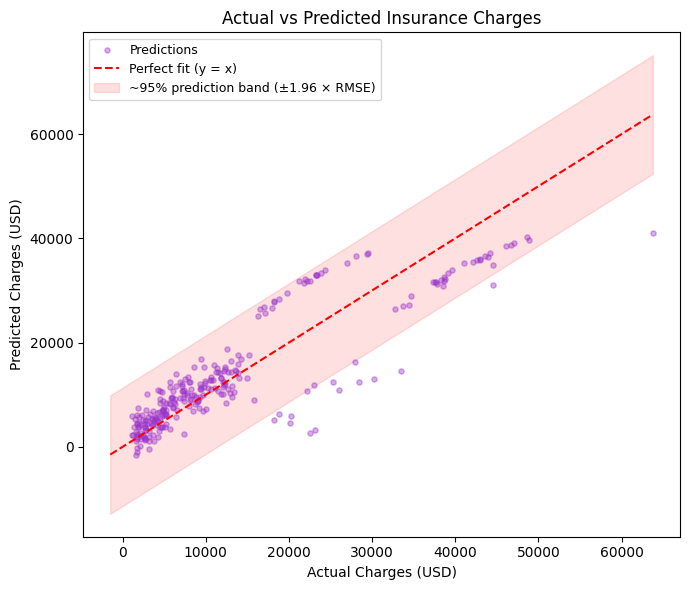

In [12]:
# Plot 5: Actual vs Predicted with Prediction Interval Band
from scipy import stats

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred, alpha=0.4, s=14, color='darkorchid', label='Predictions', zorder=3)

# Perfect fit line
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect fit (y = x)', zorder=4)

# Approximate prediction interval: ±1.96 * RMSE band around the perfect-fit line
rmse_band = np.sqrt(mean_squared_error(y_test, y_pred))
x_line = np.linspace(lims[0], lims[1], 300)
ax.fill_between(x_line, x_line - 1.96 * rmse_band, x_line + 1.96 * rmse_band,
                alpha=0.12, color='red', label='~95% prediction band (±1.96 × RMSE)')

ax.set_xlabel('Actual Charges (USD)')
ax.set_ylabel('Predicted Charges (USD)')
ax.set_title('Actual vs Predicted Insurance Charges')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


**Interpretation:** Points close to the red dashed line indicate accurate predictions. The model performs well for lower charge values but tends to underestimate very high charges (top-right area), which is expected given the right-skewed distribution of the target variable. Overall the model captures the main patterns in the data effectively.


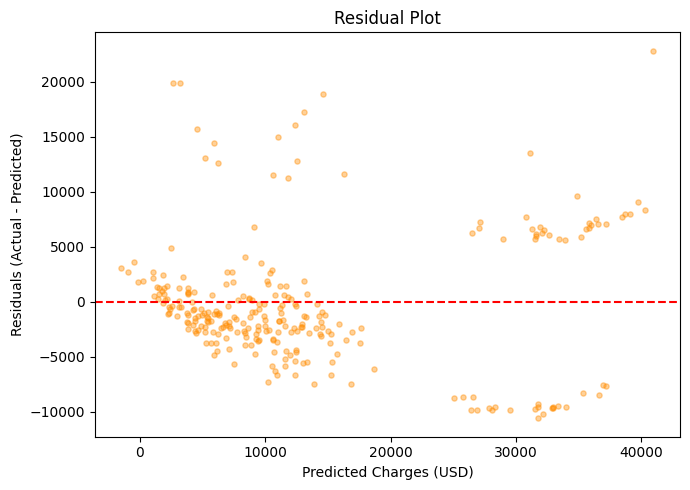

In [13]:
# Plot 6: Residual Plot
residuals = y_test - y_pred

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_pred, residuals, alpha=0.4, s=14, color='darkorange')
ax.axhline(y=0, color='r', linestyle='--', lw=1.5)
ax.set_xlabel('Predicted Charges (USD)')
ax.set_ylabel('Residuals (Actual - Predicted)')
ax.set_title('Residual Plot')
plt.tight_layout()
plt.show()


**Interpretation:** Ideally, residuals should be randomly scattered around zero with no pattern. The plot shows that residuals are roughly centered around zero for lower predicted values, but there is a fan-shaped spread (heteroscedasticity) at higher predicted values — the model tends to underestimate high-cost individuals. This is expected given the right-skewed target distribution and suggests that a log-transformation of charges or a non-linear model could improve performance for high-risk patients.


## 6. Conclusions
The multiple linear regression model achieves an **R² of 0.7833**, meaning it explains approximately **78% of the variance** in insurance charges using six demographic and health features. The **RMSE is $5,799.59**, representing the average prediction error.

Key findings:
- **Smoker status** is by far the most influential predictor, adding roughly **$23,648** to predicted charges.
- **Age** contributes approximately **$257** per additional year.
- **BMI** adds approximately **$336** per unit increase.
- **Sex** and **region** have minimal impact on charges.

The model is a solid baseline. Predictive accuracy could potentially be improved further by applying a log transformation to the target variable or using ensemble methods such as Random Forest, which can capture non-linear interactions between features.
